<a href="https://colab.research.google.com/github/manlikejuniorrr/Hi-ya-/blob/main/Pneumonia_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## STEP 1: Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import os


## STEP 2: Dataset Acquisition and Preparation

✓ Kaggle credentials successfully loaded from Colab Secrets!
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:57<00:00, 42.5MB/s]



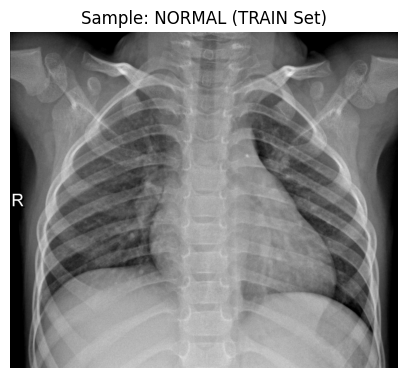

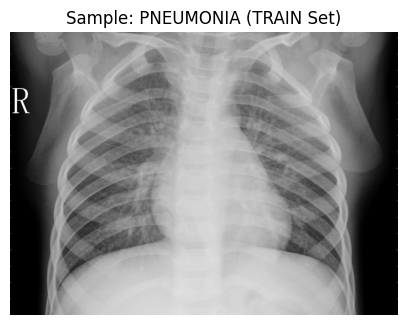

In [ ]:
import matplotlib.image as mpimg
from google.colab import userdata

# 1. Retrieve Kaggle credentials securely from Colab Secrets
try:
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("✓ Kaggle credentials successfully loaded from Colab Secrets!")
except Exception as e:
    print("Error: Please make sure you have 'KAGGLE_USERNAME' and 'KAGGLE_KEY' defined in your Colab Secrets (key icon) and notebook access is toggled ON.")
    raise e

# 2. Download and extract the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d dataset

# 3. Define directory paths
base_dir = 'dataset/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# 4. Helper function to display sample images
def show_samples(directory, label):
    label_path = os.path.join(directory, label)
    # Get the first file that is actually an image (ignores hidden system files like .DS_Store)
    valid_images = [f for f in os.listdir(label_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if valid_images:
        img_path = os.path.join(label_path, valid_images[0])
        img = mpimg.imread(img_path)
        plt.figure(figsize=(5, 5))
        plt.imshow(img, cmap='gray')
        plt.title(f"Sample: {label} ({directory.split('/')[-1].upper()} Set)")
        plt.axis('off')
        plt.show()
    else:
        print(f"No valid images found in {label_path}")

# Display samples from the training directory
show_samples(train_dir, 'NORMAL')
show_samples(train_dir, 'PNEUMONIA')

## STEP 3: Data Preprocessing

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Baseline Preprocessing: Normalization only
baseline_datagen = ImageDataGenerator(rescale=1./255)

train_generator = baseline_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_generator = baseline_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
test_generator = baseline_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## STEP 4: CNN Model Development




In [ ]:
from tensorflow.keras import layers, models

# Building a standard custom CNN
baseline_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary classification (Normal vs Pneumonia)
])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## STEP 5: Model Training and Evaluation

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 303ms/step - accuracy: 0.9893 - loss: 0.0228 - val_accuracy: 0.8125 - val_loss: 0.8358
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 301ms/step - accuracy: 0.9971 - loss: 0.0091 - val_accuracy: 0.8750 - val_loss: 0.7072
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 298ms/step - accuracy: 0.9992 - loss: 0.0019 - val_accuracy: 0.8125 - val_loss: 1.7461
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 302ms/step - accuracy: 0.9975 - loss: 0.0094 - val_accuracy: 0.8750 - val_loss: 1.5587
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 300ms/step - accuracy: 0.9866 - loss: 0.0411 - val_accuracy: 0.8750 - val_loss: 0.9115
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 295ms/step - accuracy: 0.9952 - loss: 0.0158 - val_accuracy: 0.8125 - val_loss: 0.5505
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 299ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.8750 - val_loss: 0.8674
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 300ms/step - accuracy: 1.0000 - loss: 6

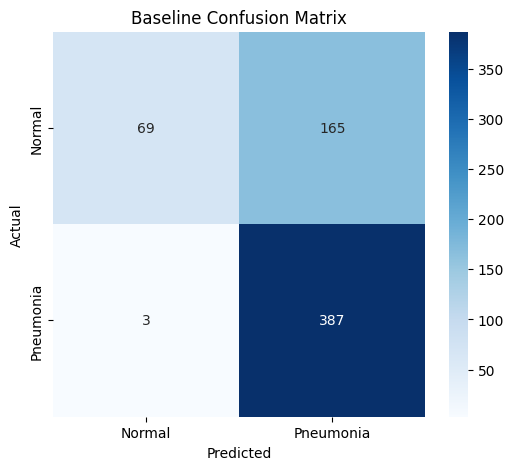

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Compile and train
baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_baseline = baseline_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate on test set
test_loss, test_acc = baseline_model.evaluate(test_generator)
print(f"Baseline Test Accuracy: {test_acc:.4f}")

# Predictions for metrics
Y_pred = baseline_model.predict(test_generator)
y_pred_classes = np.round(Y_pred).astype(int)
y_true = test_generator.classes

# Evaluation Metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['Normal', 'Pneumonia']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Baseline Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## STEP 6: Model Optimization



In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1. Data Augmentation
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_generator_aug = train_datagen_aug.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

# 2. Transfer Learning Base
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Freeze base layers

# 3. Build Optimized Model with Dropout and Batch Normalization
optimized_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(), # Batch Norm
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),         # Dropout to prevent overfitting
    layers.Dense(1, activation='sigmoid')
])

optimized_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 4. Callbacks: Early Stopping, ReduceLROnPlateau, Checkpointing
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6),
    ModelCheckpoint('best_optimized_model.h5', save_best_only=True)
]

# Train Optimized Model
history_optimized = optimized_model.fit(
    train_generator_aug,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks
)

# Compare Performance
opt_test_loss, opt_test_acc = optimized_model.evaluate(test_generator)
print(f"Optimized Test Accuracy: {opt_test_acc:.4f} (Compared to Baseline: {test_acc:.4f})")

Found 5216 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.8563 - loss: 0.3412

163/163 ━━━━━━━━━━━━━━━━━━━━ 130s 682ms/step - accuracy: 0.9089 - loss: 0.2300 - val_accuracy: 0.6875 - val_loss: 0.5727 - learning_rate: 0.0010
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9391 - loss: 0.1581

163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 591ms/step - accuracy: 0.9417 - loss: 0.1494 - val_accuracy: 0.8125 - val_loss: 0.3967 - learning_rate: 0.0010
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9507 - loss: 0.1302

163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 594ms/step - accuracy: 0.9486 - loss: 0.1358 - val_accuracy: 0.8750 - val_loss: 0.2784 - learning_rate: 0.0010
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 603ms/step - accuracy: 0.9536 - loss: 0.1199 - val_accuracy: 0.7500 - val_loss: 0.3510 - learning_rate: 0.0010
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 608ms/step - accuracy: 0.9532 - loss: 0.1244 - val_accuracy: 0.7500 - val_loss: 0.4130 - learning_rate: 0.0010
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 607ms/step - accuracy: 0.9576 - loss: 0.1113 - val_accuracy: 0.7500 - val_loss: 0.3860 - learning_rate: 2.0000e-04
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 195ms/step - accuracy: 0.8958 - loss: 0.2729
Optimized Test Accuracy: 0.8958 (Compared to Baseline: 0.7308)


## STEP 6: Testing with New Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


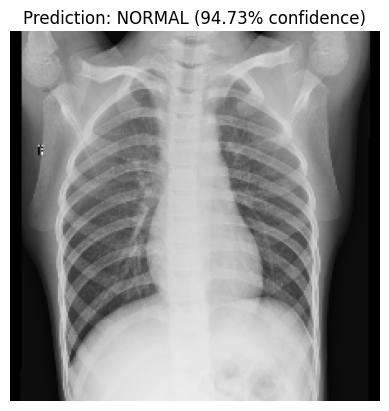

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


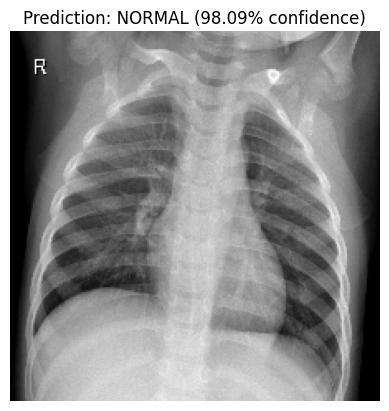

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


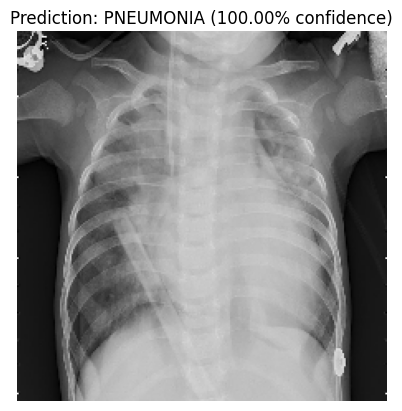

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


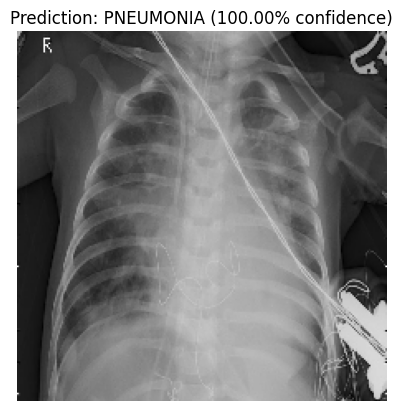

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


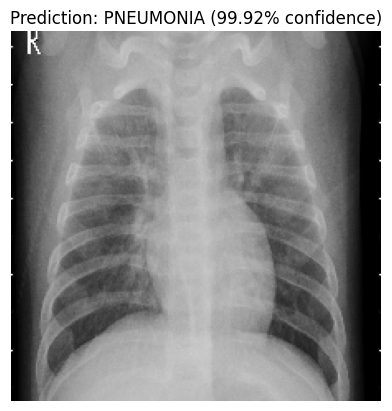

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_new_image(model, img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0 # Normalize

    prediction = model.predict(img_array)[0][0]

    plt.imshow(img)
    plt.axis('off')
    if prediction > 0.5:
        plt.title(f"Prediction: PNEUMONIA ({prediction:.2%} confidence)")
    else:
        plt.title(f"Prediction: NORMAL ({(1 - prediction):.2%} confidence)")
    plt.show()

# Test with 5 unseen images from the test set directory
test_normals = os.listdir(os.path.join(test_dir, 'NORMAL'))[:2]
test_pneumonias = os.listdir(os.path.join(test_dir, 'PNEUMONIA'))[:3]

for img_file in test_normals:
    predict_new_image(optimized_model, os.path.join(test_dir, 'NORMAL', img_file))
for img_file in test_pneumonias:
    predict_new_image(optimized_model, os.path.join(test_dir, 'PNEUMONIA', img_file))

## STEP 7: Model Saving and Deployment

In [ ]:
import tensorflow as tf

# 1. Save using the modern native Keras format (replaces .h5)
optimized_model.save('final_pneumonia_model.keras')
print("✓ Model saved in native Keras format.")

# 2. Convert to TensorFlow Lite
# We point the converter to the newly saved native Keras file
converter = tf.lite.TFLiteConverter.from_keras_model(optimized_model) # Corrected: use from_keras_model with the model object

tflite_model = converter.convert()

# Save the TFLite file
with open('pneumonia_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✓ Lightweight TFLite model successfully generated and saved!")

✓ Model saved in native Keras format.
Saved artifact at '/tmp/tmpg34r54ye'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_191')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140575494673168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571396211728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571396225360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140572156852176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140575494673360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571396224976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571396217104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571396225936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571396213840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140571396226704: TensorSpec(shape=(), dtyp

In [ ]:
# 1. Install Gradio
!pip install -q gradio

import gradio as gr
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from PIL import Image

# 2. Load your optimized model
model = tf.keras.models.load_model('final_pneumonia_model.keras')

# 3. Define the prediction function that the UI will use
def predict_xray(img):
    # Gradio passes a PIL Image, we need to resize and format it for our CNN
    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0 # Normalize just like in training

    # Predict
    prediction = model.predict(img_array)[0][0]

    # Format the output for the UI
    if prediction > 0.5:
        return {"Pneumonia Detected": float(prediction), "Normal": float(1 - prediction)}
    else:
        return {"Normal": float(1 - prediction), "Pneumonia Detected": float(prediction)}

# 4. Build the Web UI
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🩻 AI Chest X-Ray Diagnostic Tool")
    gr.Markdown("Upload a chest X-ray image to detect the presence of pneumonia using our optimized MobileNetV2 CNN.")

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Chest X-Ray")
            submit_btn = gr.Button("Run Diagnosis", variant="primary")

        with gr.Column():
            label_output = gr.Label(num_top_classes=2, label="AI Confidence Score")

    # Link the button to the function
    submit_btn.click(fn=predict_xray, inputs=image_input, outputs=label_output)

# 5. Launch the app!
demo.launch(share=True) # share=True creates a public web link you can put in your presentation!

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/tmp/ipykernel_439/553448241.py:31: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://38b4a9a53ac0770f3e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Deletes the entire dataset folder and zip file
!rm -rf dataset chest-xray-pneumonia.zip

# Deletes old saved models
!rm -rf final_pneumonia_model.h5 final_pneumonia_model.keras pneumonia_model.tflite